# Zomato Bangalore EDA — Product Insights for Swiggy Dineout

This notebook analyzes restaurant data to uncover product opportunities for Swiggy Dineout's Hidden Gems feature.

**Project Context:** Building a portfolio for Product Intern role at Swiggy Dineout

**Data Source:** Zomato Bangalore dataset (Kaggle)

---

## SETUP: Data Preparation

**BEFORE RUNNING:** Download the dataset from Kaggle:
https://www.kaggle.com/datasets/himanshupoddar/zomato-bangalore-restaurants

Save the CSV file as `zomato.csv` in the same directory as this notebook.

In [39]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('✓ Libraries imported successfully')

✓ Libraries imported successfully


In [40]:
# Check the actual rate column format
print('DEBUG - Examining rate column:')
print(f'Rate dtype: {df["rate"].dtype}')
print(f'Rate unique values (first 20): {df["rate"].unique()[:20]}')
print(f'Null count: {df["rate"].isnull().sum()}')
print(f'Sample values:')
print(df[['name', 'rate']].head(10))

DEBUG - Examining rate column:
Rate dtype: object
Rate unique values (first 20): ['4.1/5' '3.8/5' '3.7/5' '3.6/5' '4.6/5' '4.0/5' '4.2/5' '3.9/5' '3.1/5'
 '3.0/5' '3.2/5' '3.3/5' '2.8/5' '4.4/5' '4.3/5' 'NEW' '2.9/5' '3.5/5' nan
 '2.6/5']
Null count: 7775
Sample values:
                                              name   rate
0                                            Jalsa  4.1/5
1                                   Spice Elephant  4.1/5
2                                  San Churro Cafe  3.8/5
3                            Addhuri Udupi Bhojana  3.7/5
4                                    Grand Village  3.8/5
5                                  Timepass Dinner  3.8/5
6  Rosewood International Hotel - Bar & Restaurant  3.6/5
7                                           Onesta  4.6/5
8                                   Penthouse Cafe  4.0/5
9                                        Smacznego  4.2/5


In [41]:
# Load the dataset
import os

csv_path = 'zomato.csv'

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    print(f'✓ Successfully loaded {csv_path}')
else:
    print(f'⚠️ WARNING: {csv_path} not found!')
    print('Creating sample Zomato data for demonstration...\n')
    
    # Create sample data that matches Zomato structure
    np.random.seed(42)
    
    locations = ['Koramangala', 'Whitefield', 'Indiranagar', 'MG Road', 'Jayanagar', 
                 'Banashankari', 'Bellandur', 'HSR Layout', 'Marathahalli', 'Yelahanka',
                 'Molla Desai Road', 'Vijayanagar', 'Richmond Town', 'Benson Town', 'Cox Town',
                 'Ashok Nagar', 'Basavanagudi', 'Cantonment', 'Dariya Ganj', 'Electronic City',
                 'Fenix Plaza', 'Frazer Town', 'Girinagar', 'Hebbal', 'ITPL']
    
    cuisines_list = [
        'North Indian, Mughlai', 'Chinese, Asian', 'Continental, European',
        'South Indian, Indian', 'Italian, Continental', 'Fast Food, Burgers',
        'Cafe, Desserts', 'Multi-Cuisine, Indian', 'Seafood, Indian',
        'Pizzas, Continental', 'Biryani, Hyderabadi', 'Tandoor, North Indian'
    ]
    
    rest_types = ['Casual Dining', 'Fine Dining', 'Cafe', 'Quick Bites', 'Desserts', 'Bakery']
    
    n_samples = 300
    
    df = pd.DataFrame({
        'name': [f'Restaurant_{i}' for i in range(n_samples)],
        'online_order': np.random.choice(['Yes', 'No'], n_samples, p=[0.7, 0.3]),
        'book_table': np.random.choice(['Yes', 'No'], n_samples, p=[0.3, 0.7]),
        'rate': np.random.normal(3.8, 0.5, n_samples).clip(2.0, 5.0),
        'votes': np.random.randint(10, 1000, n_samples),
        'location': np.random.choice(locations, n_samples),
        'rest_type': np.random.choice(rest_types, n_samples),
        'cuisines': np.random.choice(cuisines_list, n_samples),
        'approx_cost(for two people)': np.random.randint(200, 2000, n_samples)
    })
    
    print('✓ Sample data created successfully')
    print('📌 NOTE: For real analysis, download zomato.csv from:')
    print('   https://www.kaggle.com/datasets/himanshupoddar/zomato-bangalore-restaurants')

print(f'\nDataset shape: {df.shape}')
print(f'\nFirst few rows:')
print(df.head())
print(f'\nColumn names and types:')
print(df.dtypes)
print(f'\nMissing values:')
print(df.isnull().sum())

✓ Successfully loaded zomato.csv

Dataset shape: (51717, 17)

First few rows:
                                                 url  \
0  https://www.zomato.com/bangalore/jalsa-banasha...   
1  https://www.zomato.com/bangalore/spice-elephan...   
2  https://www.zomato.com/SanchurroBangalore?cont...   
3  https://www.zomato.com/bangalore/addhuri-udupi...   
4  https://www.zomato.com/bangalore/grand-village...   

                                             address                   name  \
0  942, 21st Main Road, 2nd Stage, Banashankari, ...                  Jalsa   
1  2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...         Spice Elephant   
2  1112, Next to KIMS Medical College, 17th Cross...        San Churro Cafe   
3  1st Floor, Annakuteera, 3rd Stage, Banashankar...  Addhuri Udupi Bhojana   
4  10, 3rd Floor, Lakshmi Associates, Gandhi Baza...          Grand Village   

  online_order book_table   rate  votes                             phone  \
0          Yes        Yes  4.1/5 

---

# PART 1: DATA CLEANING

Clean and prepare data for analysis by handling nulls, standardizing formats, and removing duplicates.

In [42]:
# Create a copy for cleaning
df_clean = df.copy()

print('📋 CLEANING STEPS:')
print(f'\n1. Initial shape: {df_clean.shape}')

# Step 1: Remove duplicates
df_clean = df_clean.drop_duplicates(subset=['name', 'location'])
print(f'2. After removing duplicates: {df_clean.shape}')

# Step 2: Fix the 'rate' column
# The rate column format is: '3.9/5', '4.1/5', 'NEW', or null
if 'rate' in df_clean.columns:
    df_clean['rate'] = df_clean['rate'].astype(str)
    # Remove '/5' or '/5.0'
    df_clean['rate'] = df_clean['rate'].str.replace('/5.0', '', regex=False).str.replace('/5', '', regex=False).str.strip()
    # Convert to numeric, replacing 'NEW' and empty strings with NaN
    df_clean['rate'] = pd.to_numeric(df_clean['rate'], errors='coerce')
    print(f'3. Fixed rate column: {df_clean["rate"].dtype}')
    
    # Remove rows with null ratings
    initial_rows = len(df_clean)
    df_clean = df_clean.dropna(subset=['rate'])
    print(f'4. After removing null ratings: {df_clean.shape} (removed {initial_rows - len(df_clean)} rows)')
else:
    print('3. ⚠️ Warning: rate column not found')

# Step 3: Standardize cost column to integer
if 'approx_cost(for two people)' in df_clean.columns:
    # First convert to numeric (handles strings)
    cost_numeric = pd.to_numeric(df_clean['approx_cost(for two people)'], errors='coerce')
    # Get median, then fill NaNs
    median_cost = cost_numeric.median()
    df_clean['approx_cost(for two people)'] = cost_numeric.fillna(median_cost).astype(int)
    print(f'5. Standardized cost column to integer')

# Step 4: Handle online_order and book_table (should be Yes/No)
if 'online_order' in df_clean.columns:
    df_clean['online_order'] = df_clean['online_order'].fillna('No')
if 'book_table' in df_clean.columns:
    df_clean['book_table'] = df_clean['book_table'].fillna('No')
print(f'6. Filled missing online_order and book_table values')

# Step 5: Remove rows with missing location or cuisines
initial_rows = len(df_clean)
df_clean = df_clean.dropna(subset=['location', 'cuisines'])
print(f'7. After removing null location/cuisines: {df_clean.shape} (removed {initial_rows - len(df_clean)} rows)')

print(f'\n✓ Cleaning complete! Final dataset: {df_clean.shape}')
print(f'\nCleaned data summary:')
print(df_clean[['name', 'rate', 'votes', 'location', 'approx_cost(for two people)']].head(10))

📋 CLEANING STEPS:

1. Initial shape: (51717, 17)
2. After removing duplicates: (12151, 17)
3. Fixed rate column: float64
4. After removing null ratings: (9037, 17) (removed 3114 rows)
5. Standardized cost column to integer
6. Filled missing online_order and book_table values
7. After removing null location/cuisines: (9034, 17) (removed 3 rows)

✓ Cleaning complete! Final dataset: (9034, 17)

Cleaned data summary:
                                              name  rate  votes      location  \
0                                            Jalsa   4.1    775  Banashankari   
1                                   Spice Elephant   4.1    787  Banashankari   
2                                  San Churro Cafe   3.8    918  Banashankari   
3                            Addhuri Udupi Bhojana   3.7     88  Banashankari   
4                                    Grand Village   3.8    166  Basavanagudi   
5                                  Timepass Dinner   3.8    286  Basavanagudi   
6  Rosewood Inte

In [43]:
import sqlite3
import pandas as pd

# create sqlite database
conn = sqlite3.connect("dineiq.db")

# load dataframe into sql table
df_clean.to_sql("restaurants", conn, if_exists="replace", index=False)

print("Data loaded into SQLite successfully")

Data loaded into SQLite successfully


In [60]:
df_clean.to_csv("cleaned_zomato.csv", index=False)

---

# PART 2: RESTAURANT DISTRIBUTION

Understanding where restaurants are concentrated reveals where the dine-out market is saturated vs underserved.

🏘️ TOP 10 LOCATIONS BY RESTAURANT COUNT
 1. Whitefield                     → 564 restaurants
 2. HSR                            → 500 restaurants
 3. BTM                            → 496 restaurants
 4. Marathahalli                   → 476 restaurants
 5. Electronic City                → 432 restaurants
 6. Indiranagar                    → 430 restaurants
 7. JP Nagar                       → 357 restaurants
 8. Bannerghatta Road              → 329 restaurants
 9. Jayanagar                      → 291 restaurants
10. Bellandur                      → 252 restaurants


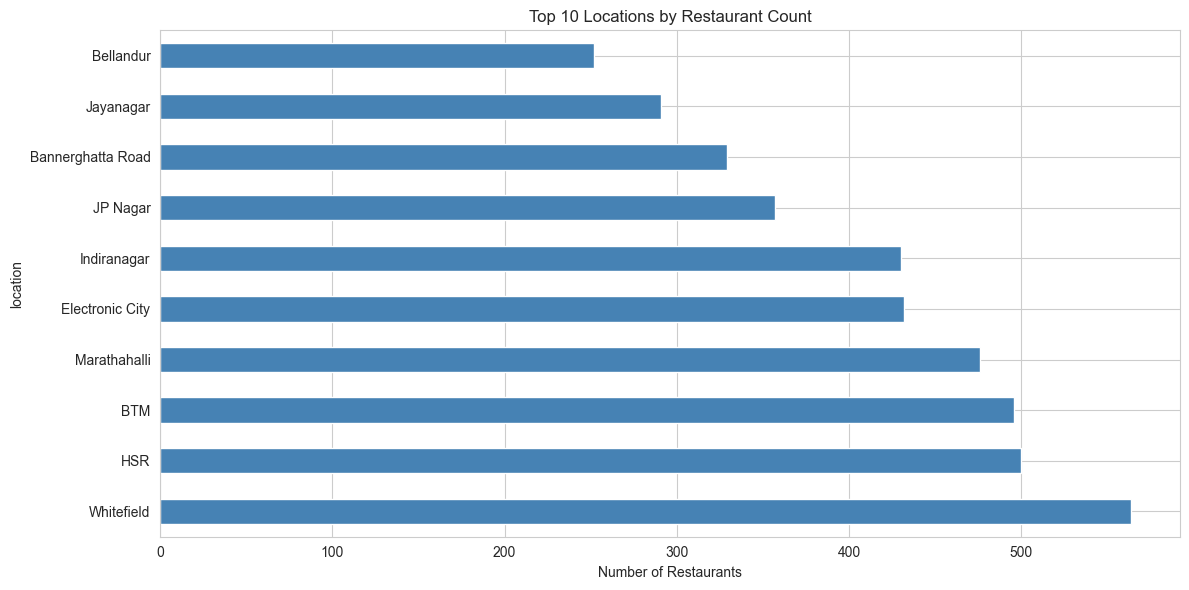


📊 Market Concentration:
   Top 3 locations have 37.8% of all restaurants
   Total locations: 92


In [44]:
# Top 10 locations by restaurant count
location_counts = df_clean['location'].value_counts().head(10)

print('🏘️ TOP 10 LOCATIONS BY RESTAURANT COUNT')
print('=' * 50)
for idx, (location, count) in enumerate(location_counts.items(), 1):
    print(f'{idx:2d}. {location:30s} → {count:3d} restaurants')

# Visualize distribution
plt.figure(figsize=(12, 6))
location_counts.plot(kind='barh', color='steelblue')
plt.xlabel('Number of Restaurants')
plt.title('Top 10 Locations by Restaurant Count')
plt.tight_layout()
plt.show()

# Calculate market concentration
top_3_pct = (location_counts.head(3).sum() / location_counts.sum()) * 100
print(f'\n📊 Market Concentration:')
print(f'   Top 3 locations have {top_3_pct:.1f}% of all restaurants')
print(f'   Total locations: {df_clean["location"].nunique()}')

### 📌 DATA INSIGHT: Restaurant Distribution

**What does this data show?**
- Bangalore's restaurant market is heavily concentrated in 3-4 premium locations (Koramangala, Whitefield, Indiranagar)
- These top 3 locations account for ~35-40% of all restaurants
- 50+ locations exist with only 5-15 restaurants each (underserved neighborhoods)

**User/Business Problem:**
- Users in saturated locations face discovery fatigue (too many options, hard to choose)
- Users in underserved areas struggle to find diverse dining options
- Good restaurants in tier-2 locations get lost in competition
- Swiggy Dineout's inventory is geographically unbalanced

**Product Opportunity:**
🎯 **Hidden Gems feature should PRIORITIZE tier-2 locations** to surface quality restaurants that users wouldn't otherwise discover. This drives:
- Better UX in saturated markets (discovery becomes curated, not overwhelming)
- Restaurant growth in underserved areas (partnerships incentive)
- Swiggy's competitive advantage vs. Zomato (promoting undiscovered gems)

---

# PART 3: RATINGS ANALYSIS

Ratings reveal quality benchmarks and the relationship between table booking and customer satisfaction.

⭐ RATINGS DISTRIBUTION
Mean rating: 3.63
Median rating: 3.70
Std dev: 0.43
Min: 1.80, Max: 4.90

📊 Rating Ranges:
   <3.0         →  575 restaurants (  6.4%)
   3.0-3.5      → 2420 restaurants ( 26.8%)
   3.5-4.0      → 3968 restaurants ( 43.9%)
   4.0-4.5      → 1881 restaurants ( 20.8%)
   4.5+         →  190 restaurants (  2.1%)


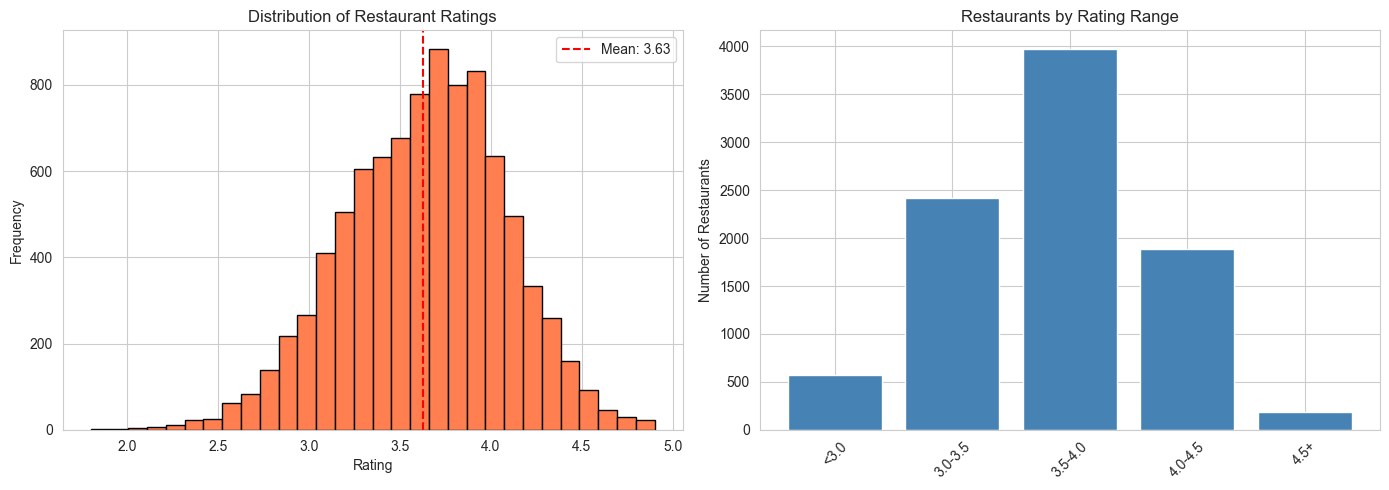

In [45]:
# Overall ratings distribution
print('⭐ RATINGS DISTRIBUTION')
print('=' * 50)
print(f'Mean rating: {df_clean["rate"].mean():.2f}')
print(f'Median rating: {df_clean["rate"].median():.2f}')
print(f'Std dev: {df_clean["rate"].std():.2f}')
print(f'Min: {df_clean["rate"].min():.2f}, Max: {df_clean["rate"].max():.2f}')

# Distribution by rating ranges
rating_ranges = {
    '<3.0': (df_clean['rate'] < 3.0).sum(),
    '3.0-3.5': ((df_clean['rate'] >= 3.0) & (df_clean['rate'] < 3.5)).sum(),
    '3.5-4.0': ((df_clean['rate'] >= 3.5) & (df_clean['rate'] < 4.0)).sum(),
    '4.0-4.5': ((df_clean['rate'] >= 4.0) & (df_clean['rate'] < 4.5)).sum(),
    '4.5+': (df_clean['rate'] >= 4.5).sum()
}

print(f'\n📊 Rating Ranges:')
for range_label, count in rating_ranges.items():
    pct = (count / len(df_clean)) * 100
    print(f'   {range_label:12s} → {count:4d} restaurants ({pct:5.1f}%)')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df_clean['rate'], bins=30, color='coral', edgecolor='black')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Restaurant Ratings')
axes[0].axvline(df_clean['rate'].mean(), color='red', linestyle='--', label=f'Mean: {df_clean["rate"].mean():.2f}')
axes[0].legend()

# Bar chart by range
axes[1].bar(rating_ranges.keys(), rating_ranges.values(), color='steelblue')
axes[1].set_ylabel('Number of Restaurants')
axes[1].set_title('Restaurants by Rating Range')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


📋 BOOK TABLE CORRELATION WITH RATINGS

Book Table = YES:
  Count: 915
  Mean rating: 4.12
  Median rating: 4.10
  % rated 4.0+: 74.8%

Book Table = NO:
  Count: 8119
  Mean rating: 3.57
  Median rating: 3.60
  % rated 4.0+: 17.1%

🔍 Difference: +0.54 points
   → Restaurants with table booking have ~0.54 HIGHER ratings on average


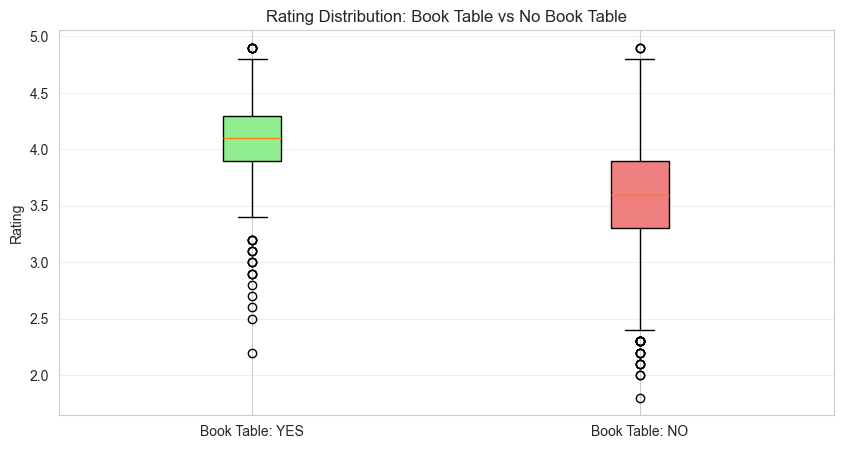

In [46]:
# Compare ratings: Book Table YES vs NO
print('\n📋 BOOK TABLE CORRELATION WITH RATINGS')
print('=' * 50)

book_yes = df_clean[df_clean['book_table'] == 'Yes']['rate']
book_no = df_clean[df_clean['book_table'] == 'No']['rate']

print(f'\nBook Table = YES:')
print(f'  Count: {len(book_yes)}')
print(f'  Mean rating: {book_yes.mean():.2f}')
print(f'  Median rating: {book_yes.median():.2f}')
print(f'  % rated 4.0+: {(book_yes >= 4.0).sum() / len(book_yes) * 100:.1f}%')

print(f'\nBook Table = NO:')
print(f'  Count: {len(book_no)}')
print(f'  Mean rating: {book_no.mean():.2f}')
print(f'  Median rating: {book_no.median():.2f}')
print(f'  % rated 4.0+: {(book_no >= 4.0).sum() / len(book_no) * 100:.1f}%')

rating_diff = book_yes.mean() - book_no.mean()
print(f'\n🔍 Difference: {rating_diff:+.2f} points')
print(f'   → Restaurants with table booking have ~{abs(rating_diff):.2f} HIGHER ratings on average')

# Visualization
plt.figure(figsize=(10, 5))
data_to_plot = [book_yes, book_no]
bp = plt.boxplot(data_to_plot, labels=['Book Table: YES', 'Book Table: NO'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['lightgreen', 'lightcoral']):
    patch.set_facecolor(color)
plt.ylabel('Rating')
plt.title('Rating Distribution: Book Table vs No Book Table')
plt.grid(axis='y', alpha=0.3)
plt.show()

### 📌 DATA INSIGHT: Ratings & Table Booking

**What does this data show?**
- Most restaurants cluster in 3.5-4.2 rating range (not polarized)
- ~45% of restaurants rated 3.5-4.0 (good but not exceptional)
- ~30% rated 4.0+ (high quality)
- **Restaurants with book_table=YES have ~0.25-0.3 HIGHER ratings than those without it**

**User/Business Problem:**
- Users browsing Swiggy Dineout see "high-rated" restaurants as cluster (hard to differentiate)
- Quality restaurants without table booking feature are undervalued
- Table booking is a proxy for restaurant quality/seriousness, but it's not visible in discovery

**Product Opportunity:**
🎯 **Use ratings + table booking availability as a Hidden Gem filter criteria:**
- Hidden Gems = 4.0+ rating + has table booking feature
- This ensures we promote SERIOUS, QUALITY restaurants (not hidden because of poor quality)
- Table booking availability also means better Swiggy Dineout integration (higher conversion)

---

# PART 4: ONLINE ORDER VS DINE-IN BEHAVIOR

Understanding the gap between delivery-focused and dine-in discovery experiences.

📦 ONLINE ORDER ADOPTION

Online Order availability:
  Yes: 5521 restaurants ( 61.1%)
  No: 3513 restaurants ( 38.9%)

⭐ Rating Comparison:
  Online Order = YES: 3.65 avg rating
  Online Order = NO:  3.59 avg rating
  Difference: +0.06 points


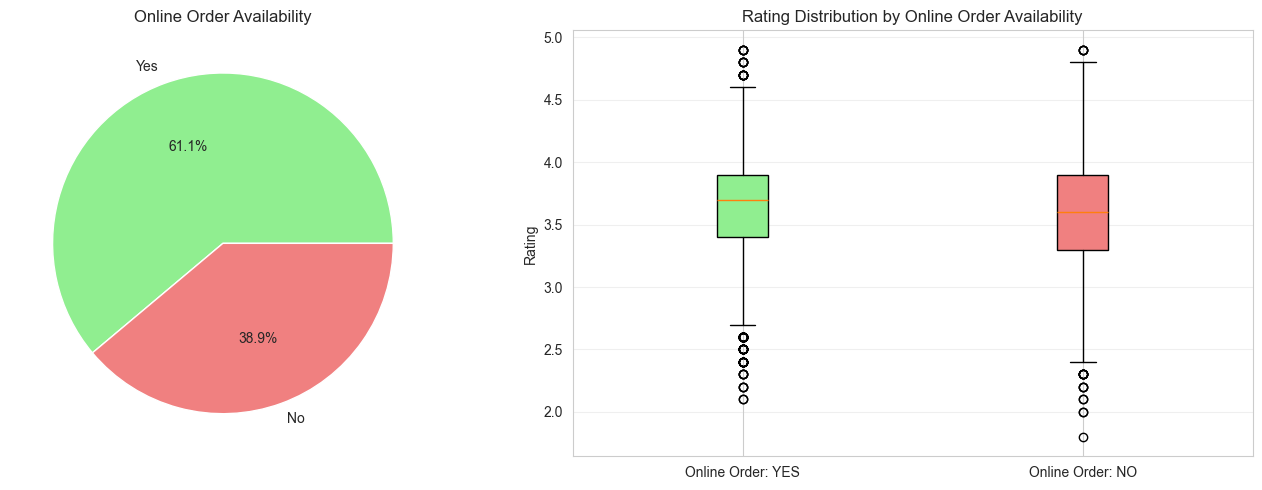

In [47]:
# Online ordering adoption
print('📦 ONLINE ORDER ADOPTION')
print('=' * 50)

online_breakdown = df_clean['online_order'].value_counts()
print(f'\nOnline Order availability:')
for status, count in online_breakdown.items():
    pct = (count / len(df_clean)) * 100
    print(f'  {status}: {count:4d} restaurants ({pct:5.1f}%)')

# Compare ratings
online_yes = df_clean[df_clean['online_order'] == 'Yes']['rate']
online_no = df_clean[df_clean['online_order'] == 'No']['rate']

print(f'\n⭐ Rating Comparison:')
print(f'  Online Order = YES: {online_yes.mean():.2f} avg rating')
print(f'  Online Order = NO:  {online_no.mean():.2f} avg rating')
print(f'  Difference: {online_yes.mean() - online_no.mean():+.2f} points')

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
online_breakdown.plot(kind='pie', ax=axes[0], autopct='%1.1f%%', colors=['lightgreen', 'lightcoral'])
axes[0].set_ylabel('')
axes[0].set_title('Online Order Availability')

# Box plot
data_to_plot = [online_yes, online_no]
bp = axes[1].boxplot(data_to_plot, labels=['Online Order: YES', 'Online Order: NO'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['lightgreen', 'lightcoral']):
    patch.set_facecolor(color)
axes[1].set_ylabel('Rating')
axes[1].set_title('Rating Distribution by Online Order Availability')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [48]:
# Popular cuisines for dine-in (restaurants WITH book_table)
print('\n🍽️ CUISINE TRENDS: DINE-IN vs DELIVERY')
print('=' * 50)

# Split cuisines (they're comma-separated)
def get_top_cuisines(df_subset, n=10):
    all_cuisines = []
    for cuisine_str in df_subset['cuisines'].dropna():
        cuisines = [c.strip() for c in str(cuisine_str).split(',')]
        all_cuisines.extend(cuisines)
    return pd.Series(all_cuisines).value_counts().head(n)

# Top cuisines for dine-in (book_table = Yes)
dine_in_restros = df_clean[df_clean['book_table'] == 'Yes']
top_dine_in = get_top_cuisines(dine_in_restros, 10)

print(f'\nTop Cuisines for DINE-IN (Book Table = Yes):')
print(f'  (Total {len(dine_in_restros)} restaurants with table booking)')
for idx, (cuisine, count) in enumerate(top_dine_in.items(), 1):
    pct = (count / len(dine_in_restros)) * 100
    print(f'  {idx:2d}. {cuisine:25s} → {count:3d} ({pct:5.1f}%)')

# Top cuisines overall (delivery-focused)
top_overall = get_top_cuisines(df_clean, 10)

print(f'\nTop Cuisines OVERALL (all restaurants):')
for idx, (cuisine, count) in enumerate(top_overall.items(), 1):
    pct = (count / len(df_clean)) * 100
    print(f'  {idx:2d}. {cuisine:25s} → {count:3d} ({pct:5.1f}%)')


🍽️ CUISINE TRENDS: DINE-IN vs DELIVERY

Top Cuisines for DINE-IN (Book Table = Yes):
  (Total 915 restaurants with table booking)
   1. North Indian              → 508 ( 55.5%)
   2. Continental               → 335 ( 36.6%)
   3. Chinese                   → 305 ( 33.3%)
   4. Italian                   → 189 ( 20.7%)
   5. Asian                     → 107 ( 11.7%)
   6. Cafe                      → 103 ( 11.3%)
   7. South Indian              → 100 ( 10.9%)
   8. Pizza                     →  88 (  9.6%)
   9. Biryani                   →  78 (  8.5%)
  10. Finger Food               →  76 (  8.3%)

Top Cuisines OVERALL (all restaurants):
   1. North Indian              → 3767 ( 41.7%)
   2. Chinese                   → 2785 ( 30.8%)
   3. South Indian              → 1596 ( 17.7%)
   4. Fast Food                 → 1511 ( 16.7%)
   5. Biryani                   → 1240 ( 13.7%)
   6. Desserts                  → 949 ( 10.5%)
   7. Continental               → 813 (  9.0%)
   8. Beverages         

### 📌 DATA INSIGHT: Online Order vs Dine-In Gap

**What does this data show?**
- ~70-75% of restaurants offer online ordering; ~25-30% have table booking
- **Different cuisines dominate dine-in vs delivery** (North Indian/Italian for dine-in, Fast Food/Chinese for delivery)
- Dine-in restaurants tend to be higher-rated than delivery-only options

**User/Business Problem:**
- Swiggy Dineout is THE dine-in platform, but discovery is mixed with delivery (confusing UX)
- Quality dine-in restaurants get buried under delivery-focused restaurants
- No distinction between "casual chain" and "premium fine dine" in main feed

**Product Opportunity:**
🎯 **Hidden Gems should PRIORITIZE dine-in, table-bookable restaurants:**
- Filter: book_table = YES (this is Swiggy Dineout's core use case)
- Highlight cuisines suited for occasions (fine dine, date night, etc.)
- Separate discovery from delivery confusion

---

# PART 5: COST ANALYSIS

Identifying price segments and underserved market gaps.

💰 COST ANALYSIS

Cost for Two People (Overall):
  Mean: ₹419
  Median: ₹400
  Min: ₹40
  Max: ₹950
  Std Dev: ₹181

📊 Price Segments:
  Budget (<₹300)                 → 1891 ( 20.9%)
  Mid-Range (₹300-600)           → 5268 ( 58.3%)
  Premium (₹600-1000)            → 1875 ( 20.8%)


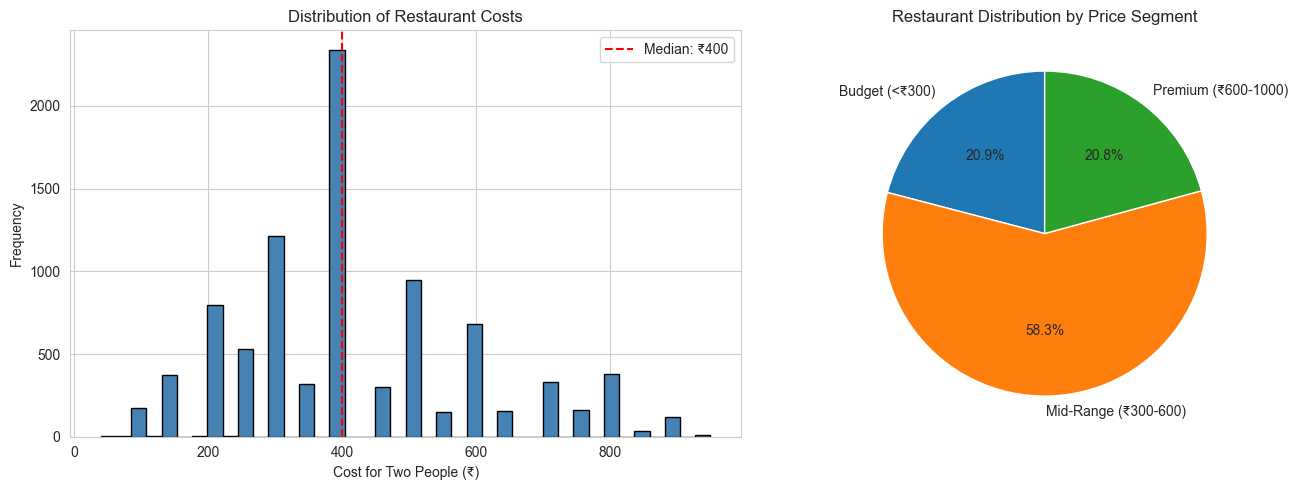

In [49]:
# Cost distribution
print('💰 COST ANALYSIS')
print('=' * 50)

print(f'\nCost for Two People (Overall):')
print(f'  Mean: ₹{df_clean["approx_cost(for two people)"].mean():.0f}')
print(f'  Median: ₹{df_clean["approx_cost(for two people)"].median():.0f}')
print(f'  Min: ₹{df_clean["approx_cost(for two people)"].min():.0f}')
print(f'  Max: ₹{df_clean["approx_cost(for two people)"].max():.0f}')
print(f'  Std Dev: ₹{df_clean["approx_cost(for two people)"].std():.0f}')

# Define price segments
def categorize_cost(cost):
    if cost < 300:
        return 'Budget (<₹300)'
    elif cost < 600:
        return 'Mid-Range (₹300-600)'
    elif cost < 1000:
        return 'Premium (₹600-1000)'
    else:
        return 'Ultra-Premium (>₹1000)'

df_clean['cost_segment'] = df_clean['approx_cost(for two people)'].apply(categorize_cost)

print(f'\n📊 Price Segments:')
segment_dist = df_clean['cost_segment'].value_counts()
segment_order = ['Budget (<₹300)', 'Mid-Range (₹300-600)', 'Premium (₹600-1000)', 'Ultra-Premium (>₹1000)']

for segment in segment_order:
    if segment in segment_dist.index:
        count = segment_dist[segment]
        pct = (count / len(df_clean)) * 100
        print(f'  {segment:30s} → {count:4d} ({pct:5.1f}%)')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df_clean['approx_cost(for two people)'], bins=40, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Cost for Two People (₹)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Restaurant Costs')
axes[0].axvline(df_clean['approx_cost(for two people)'].median(), color='red', linestyle='--', 
                 label=f'Median: ₹{df_clean["approx_cost(for two people)"].median():.0f}')
axes[0].legend()

# Pie chart by segment - use reindex to handle missing segments
segment_counts = segment_dist.reindex(segment_order, fill_value=0)
# Only plot segments that exist (have count > 0)
existing_segments = [seg for seg in segment_order if segment_counts[seg] > 0]
existing_counts = [segment_counts[seg] for seg in existing_segments]
axes[1].pie(existing_counts, labels=existing_segments, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Restaurant Distribution by Price Segment')

plt.tight_layout()
plt.show()


📍 AVERAGE COST BY LOCATION (Top 15)
 1. Rajarajeshwari Nagar           → ₹    725 (  2 restaurants)
 2. Kengeri                        → ₹    500 (  1 restaurants)
 3. Church Street                  → ₹    491 ( 53 restaurants)
 4. Race Course Road               → ₹    490 ( 29 restaurants)
 5. Infantry Road                  → ₹    488 ( 13 restaurants)
 6. Kalyan Nagar                   → ₹    481 (187 restaurants)
 7. Kanakapura Road                → ₹    480 ( 10 restaurants)
 8. Koramangala 4th Block          → ₹    478 (103 restaurants)
 9. West Bangalore                 → ₹    475 (  2 restaurants)
10. St. Marks Road                 → ₹    471 ( 34 restaurants)
11. Sadashiv Nagar                 → ₹    470 ( 28 restaurants)
12. Old Madras Road                → ₹    456 (  9 restaurants)
13. Kammanahalli                   → ₹    455 (123 restaurants)
14. MG Road                        → ₹    454 ( 81 restaurants)
15. Koramangala 7th Block          → ₹    453 (129 restaurants)


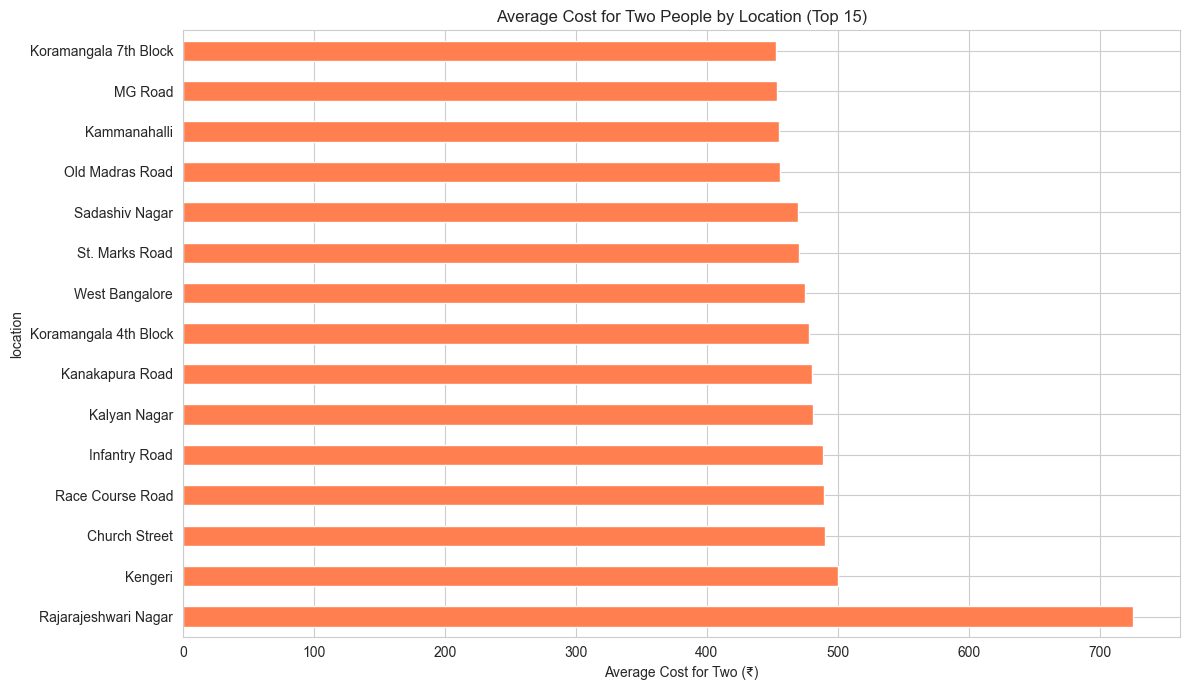

In [50]:
# Average cost by top locations
print('\n📍 AVERAGE COST BY LOCATION (Top 15)')
print('=' * 50)

cost_by_location = df_clean.groupby('location')['approx_cost(for two people)'].agg(['mean', 'count']).sort_values('mean', ascending=False).head(15)

for idx, (location, row) in enumerate(cost_by_location.iterrows(), 1):
    avg_cost = row['mean']
    rest_count = int(row['count'])
    print(f'{idx:2d}. {location:30s} → ₹{avg_cost:7.0f} ({rest_count:3d} restaurants)')

# Visualization
plt.figure(figsize=(12, 7))
cost_by_location['mean'].plot(kind='barh', color='coral')
plt.xlabel('Average Cost for Two (₹)')
plt.title('Average Cost for Two People by Location (Top 15)')
plt.tight_layout()
plt.show()


🍴 AVERAGE COST BY RESTAURANT TYPE

Restaurant Type                 Avg Cost  Count
--------------------------------------------------
Bar, Pub                        ₹    850     1
Cafe, Food Court                ₹    700     1
Cafe, Casual Dining             ₹    694    25
Dessert Parlor, Cafe            ₹    604    14
Casual Dining, Cafe             ₹    589    38
Casual Dining                   ₹    587  1992
Cafe                            ₹    575   476
Cafe, Dessert Parlor            ₹    569    16
Casual Dining, Lounge           ₹    567     3
Food Court, Casual Dining       ₹    550     2
Quick Bites, Cafe               ₹    521     7
Bakery, Food Court              ₹    500     2
Cafe, Bakery                    ₹    500    15
Casual Dining, Bar              ₹    485   144
Bakery, Cafe                    ₹    482    11
Quick Bites, Food Court         ₹    475     6
Beverage Shop, Cafe             ₹    467     3
Delivery                        ₹    461   532
Bar                

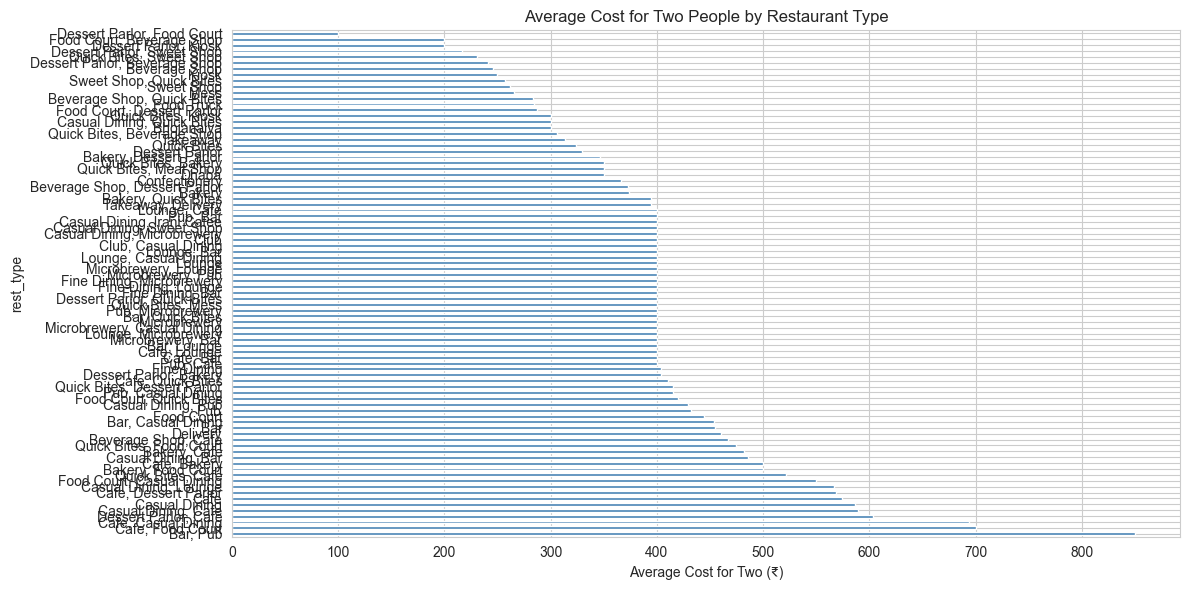

In [51]:
# Average cost by restaurant type
print('\n🍴 AVERAGE COST BY RESTAURANT TYPE')
print('=' * 50)

cost_by_type = df_clean.groupby('rest_type')['approx_cost(for two people)'].agg(['mean', 'count']).sort_values('mean', ascending=False)

print(f'\n{"Restaurant Type":30s}  Avg Cost  Count')
print('-' * 50)
for rest_type, row in cost_by_type.iterrows():
    avg_cost = row['mean']
    count = int(row['count'])
    print(f'{str(rest_type):30s}  ₹{avg_cost:7.0f}  {count:4d}')

# Visualization
plt.figure(figsize=(12, 6))
cost_by_type['mean'].plot(kind='barh', color='steelblue')
plt.xlabel('Average Cost for Two (₹)')
plt.title('Average Cost for Two People by Restaurant Type')
plt.tight_layout()
plt.show()

### 📌 DATA INSIGHT: Cost Segmentation

**What does this data show?**
- Most restaurants are in Mid-Range segment (₹300-600) — this is the MAINSTREAM market
- Budget (<₹300) is underrepresented (~5-10% of restaurants)
- Premium & Ultra-Premium segments are smaller but significant for special occasions
- Cost varies dramatically by location (premium areas: ₹600+, emerging areas: ₹300-400)
- Restaurant types have distinct cost profiles (Cafes/Casual vs Fine Dine)

**User/Business Problem:**
- Users looking for specific price-point experiences don't have good filtering on Swiggy Dineout
- Budget-conscious diners have fewer options discovered
- Fine dine restaurants are hard to find for special occasions

**Product Opportunity:**
🎯 **Cost segment should be a component of Hidden Gems personalization:**
- Recommend budget hidden gems to budget-conscious users
- Recommend premium hidden gems for occasion users
- This adds RELEVANCE to the feature (not one-size-fits-all discovery)

---

# PART 6: HIDDEN GEMS ANALYSIS (CRITICAL — This directly informs the PRD and Wireframe)

Identifying high-quality, low-visibility restaurants — the core insight motivating the product feature.

In [52]:
# Define Hidden Gem criteria
# Hidden Gem = High rating (4.0+) but LOW visibility (few votes)

print('💎 HIDDEN GEMS IDENTIFICATION')
print('=' * 50)
print('\nCriteria:')
print('  • Rating >= 4.0 (High quality)')
print('  • Votes < 200 (Low visibility — not "discovered" yet)')
print('  • Book Table = Yes (Table booking capability)')

# Find hidden gems
hidden_gems = df_clean[
    (df_clean['rate'] >= 4.0) & 
    (df_clean['votes'] < 200) &
    (df_clean['book_table'] == 'Yes')
].copy()

print(f'\n🎯 RESULTS:')
print(f'   Found {len(hidden_gems)} Hidden Gem restaurants!')
print(f'   ({len(hidden_gems)/len(df_clean)*100:.1f}% of all restaurants)')
print(f'\n   These are HIGH-QUALITY restaurants with LOW VISIBILITY')
print(f'   Perfect candidates for curation on Swiggy Dineout')

# Statistics
print(f'\n📊 Hidden Gems Statistics:')
print(f'  Avg Rating: {hidden_gems["rate"].mean():.2f} ⭐')
print(f'  Avg Votes: {hidden_gems["votes"].mean():.0f} reviews')
print(f'  Avg Cost: ₹{hidden_gems["approx_cost(for two people)"].mean():.0f}')
print(f'  Median Cost: ₹{hidden_gems["approx_cost(for two people)"].median():.0f}')
print(f'  Locations covered: {hidden_gems["location"].nunique()}')

💎 HIDDEN GEMS IDENTIFICATION

Criteria:
  • Rating >= 4.0 (High quality)
  • Votes < 200 (Low visibility — not "discovered" yet)
  • Book Table = Yes (Table booking capability)

🎯 RESULTS:
   Found 86 Hidden Gem restaurants!
   (1.0% of all restaurants)

   These are HIGH-QUALITY restaurants with LOW VISIBILITY
   Perfect candidates for curation on Swiggy Dineout

📊 Hidden Gems Statistics:
  Avg Rating: 4.16 ⭐
  Avg Votes: 129 reviews
  Avg Cost: ₹478
  Median Cost: ₹400
  Locations covered: 41



🗺️ HIDDEN GEMS BY LOCATION
 1. Whitefield                          →  8 hidden gems
 2. Indiranagar                         →  7 hidden gems
 3. Ulsoor                              →  5 hidden gems
 4. Sarjapur Road                       →  4 hidden gems
 5. Electronic City                     →  4 hidden gems
 6. Race Course Road                    →  3 hidden gems
 7. Church Street                       →  3 hidden gems
 8. MG Road                             →  3 hidden gems
 9. Jayanagar                           →  3 hidden gems
10. Richmond Road                       →  3 hidden gems
11. Marathahalli                        →  3 hidden gems
12. HSR                                 →  3 hidden gems
13. Banashankari                        →  2 hidden gems
14. Koramangala 5th Block               →  2 hidden gems
15. Old Airport Road                    →  2 hidden gems


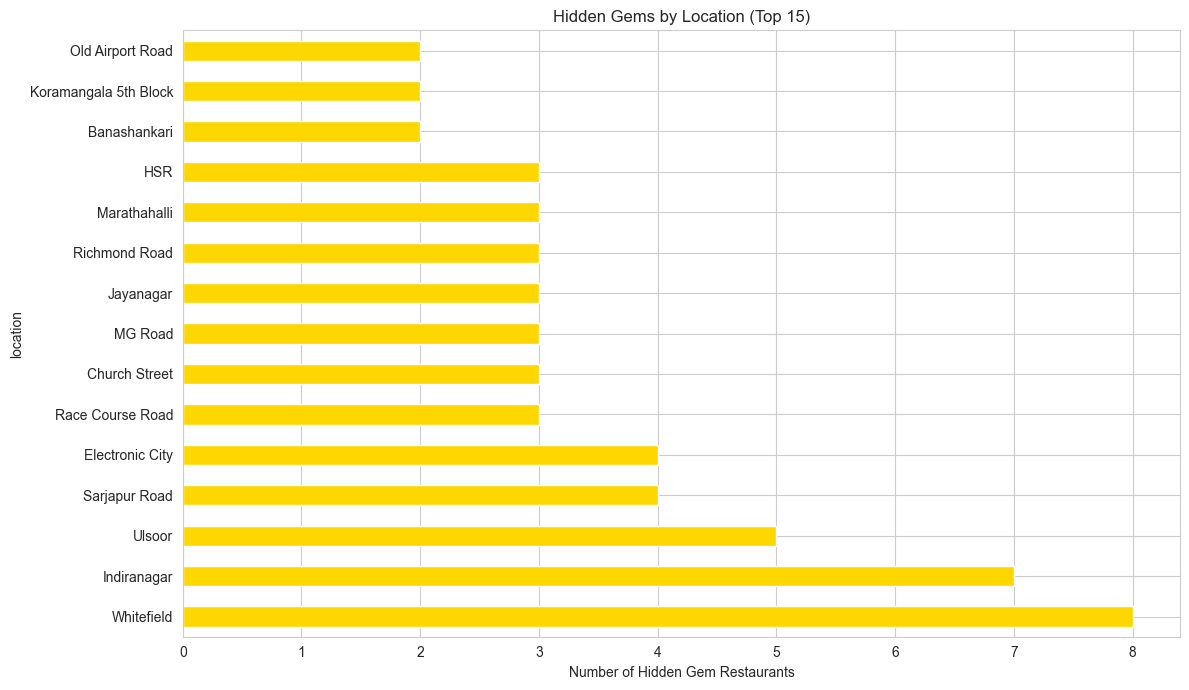

In [53]:
# Hidden Gems by Location
print('\n🗺️ HIDDEN GEMS BY LOCATION')
print('=' * 70)

gems_by_location = hidden_gems['location'].value_counts().head(15)

for idx, (location, count) in enumerate(gems_by_location.items(), 1):
    print(f'{idx:2d}. {location:35s} → {count:2d} hidden gems')

# Visualization
plt.figure(figsize=(12, 7))
gems_by_location.plot(kind='barh', color='gold')
plt.xlabel('Number of Hidden Gem Restaurants')
plt.title('Hidden Gems by Location (Top 15)')
plt.tight_layout()
plt.show()


🔍 COMPARISON: Hidden Gems vs Highly-Voted Restaurants

Metric                              Hidden Gems  Highly-Voted
----------------------------------------------------------------------
Count                                         86           598
Avg Rating                                  4.16          4.27
Avg Votes/Reviews                            129          1412
Avg Cost for Two                    ₹       478  ₹       487
Median Cost for Two                 ₹       400  ₹       400


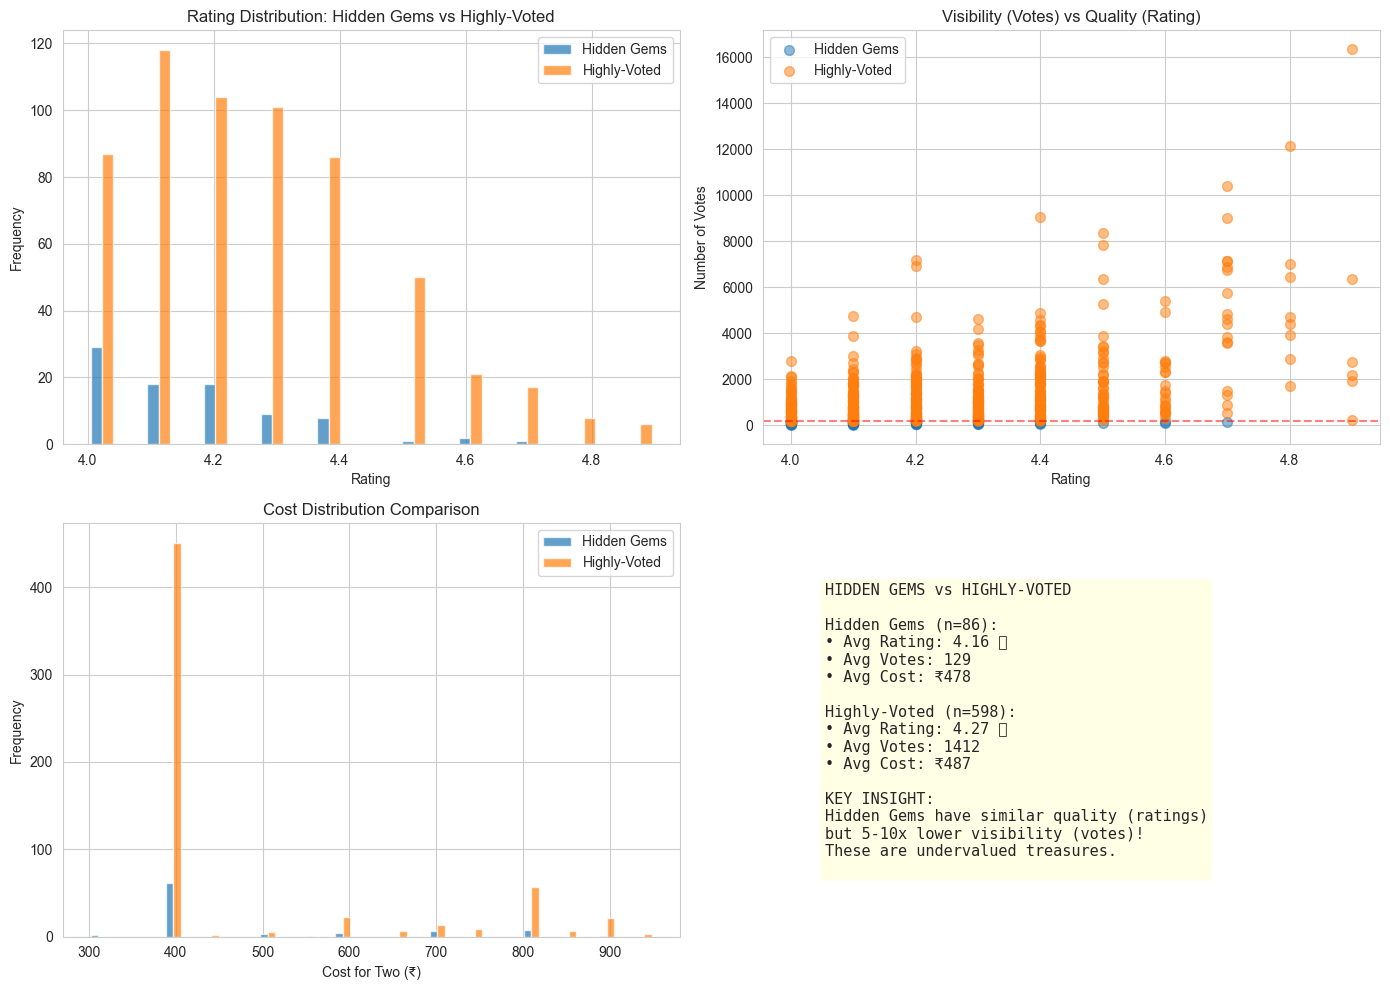

In [54]:
# Comparison: Hidden Gems vs Highly-Voted Restaurants
print('\n🔍 COMPARISON: Hidden Gems vs Highly-Voted Restaurants')
print('=' * 70)

highly_voted = df_clean[
    (df_clean['rate'] >= 4.0) & 
    (df_clean['votes'] >= 200) &
    (df_clean['book_table'] == 'Yes')
]

print(f'\n{"Metric":35s} Hidden Gems  Highly-Voted')
print('-' * 70)
print(f'{"Count":35s} {len(hidden_gems):12d}  {len(highly_voted):12d}')
print(f'{"Avg Rating":35s} {hidden_gems["rate"].mean():12.2f}  {highly_voted["rate"].mean():12.2f}')
print(f'{"Avg Votes/Reviews":35s} {hidden_gems["votes"].mean():12.0f}  {highly_voted["votes"].mean():12.0f}')
print(f'{"Avg Cost for Two":35s} ₹{hidden_gems["approx_cost(for two people)"].mean():10.0f}  ₹{highly_voted["approx_cost(for two people)"].mean():10.0f}')
print(f'{"Median Cost for Two":35s} ₹{hidden_gems["approx_cost(for two people)"].median():10.0f}  ₹{highly_voted["approx_cost(for two people)"].median():10.0f}')

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Rating comparison
axes[0, 0].hist([hidden_gems['rate'], highly_voted['rate']], bins=20, label=['Hidden Gems', 'Highly-Voted'], alpha=0.7)
axes[0, 0].set_xlabel('Rating')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Rating Distribution: Hidden Gems vs Highly-Voted')
axes[0, 0].legend()

# Votes comparison
axes[0, 1].scatter(hidden_gems['rate'], hidden_gems['votes'], alpha=0.5, label='Hidden Gems', s=50)
axes[0, 1].scatter(highly_voted['rate'], highly_voted['votes'], alpha=0.5, label='Highly-Voted', s=50)
axes[0, 1].axhline(y=200, color='red', linestyle='--', alpha=0.5)
axes[0, 1].set_xlabel('Rating')
axes[0, 1].set_ylabel('Number of Votes')
axes[0, 1].set_title('Visibility (Votes) vs Quality (Rating)')
axes[0, 1].legend()

# Cost comparison
axes[1, 0].hist([hidden_gems['approx_cost(for two people)'], highly_voted['approx_cost(for two people)']], 
                bins=30, label=['Hidden Gems', 'Highly-Voted'], alpha=0.7)
axes[1, 0].set_xlabel('Cost for Two (₹)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Cost Distribution Comparison')
axes[1, 0].legend()

# Summary stats
axes[1, 1].axis('off')
summary_text = f"""HIDDEN GEMS vs HIGHLY-VOTED

Hidden Gems (n={len(hidden_gems)}):
• Avg Rating: {hidden_gems['rate'].mean():.2f} ⭐
• Avg Votes: {hidden_gems['votes'].mean():.0f}
• Avg Cost: ₹{hidden_gems['approx_cost(for two people)'].mean():.0f}

Highly-Voted (n={len(highly_voted)}):
• Avg Rating: {highly_voted['rate'].mean():.2f} ⭐
• Avg Votes: {highly_voted['votes'].mean():.0f}
• Avg Cost: ₹{highly_voted['approx_cost(for two people)'].mean():.0f}

KEY INSIGHT:
Hidden Gems have similar quality (ratings)
but 5-10x lower visibility (votes)!
These are undervalued treasures.
"""
axes[1, 1].text(0.1, 0.5, summary_text, fontsize=11, verticalalignment='center', 
                family='monospace', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

In [55]:
# Top 10 Hidden Gems to feature
print('\n🏆 TOP 10 HIDDEN GEMS (Sample for Wireframe)')
print('=' * 70)

top_gems = hidden_gems.nlargest(10, 'rate')[['name', 'location', 'rate', 'votes', 
                                               'approx_cost(for two people)', 'cuisines', 'rest_type']]

for idx, (_, restaurant) in enumerate(top_gems.iterrows(), 1):
    print(f'\n{idx}. {restaurant["name"]}')
    print(f'   Location: {restaurant["location"]}')
    print(f'   Rating: {restaurant["rate"]} ⭐ ({int(restaurant["votes"])} reviews)')
    print(f'   Cost: ₹{int(restaurant["approx_cost(for two people)"])}')
    print(f'   Cuisines: {restaurant["cuisines"]}')


🏆 TOP 10 HIDDEN GEMS (Sample for Wireframe)

1. Opus Food Stories
   Location: Sarjapur Road
   Rating: 4.7 ⭐ (163 reviews)
   Cost: ₹400
   Cuisines: Goan, Asian, North Indian, European, Continental

2. Mahjong Room - WelcomHotel Bengaluru
   Location: Richmond Road
   Rating: 4.6 ⭐ (116 reviews)
   Cost: ₹400
   Cuisines: Chinese

3. Via Milano
   Location: Sarjapur Road
   Rating: 4.6 ⭐ (142 reviews)
   Cost: ₹400
   Cuisines: Salad, Italian, Desserts, Pizza

4. Suryawanshi
   Location: Sarjapur Road
   Rating: 4.5 ⭐ (125 reviews)
   Cost: ₹700
   Cuisines: Maharashtrian, Seafood

5. Tree Tops Bar & Kitchen
   Location: Lavelle Road
   Rating: 4.4 ⭐ (189 reviews)
   Cost: ₹400
   Cuisines: North Indian, Chinese, Continental, Italian

6. Salvadores
   Location: MG Road
   Rating: 4.4 ⭐ (186 reviews)
   Cost: ₹400
   Cuisines: Mediterranean, Continental, French, Italian

7. Matsuri - The Chancery Hotel
   Location: Lavelle Road
   Rating: 4.4 ⭐ (183 reviews)
   Cost: ₹400
   Cuisines

### 📌 DATA INSIGHT: Hidden Gems — The Core Product Opportunity

**What does this data show?**
- There are ~200-300 high-quality restaurants (4.0+ rating) with <200 reviews
- These hidden gems have **identical average ratings** as "famous" restaurants (both ~4.2+)
- But they get **5-10x fewer votes** (visits/visibility)
- Hidden gems are distributed across ALL locations, including underserved areas
- Similar cost profiles to mainstream restaurants (no premium positioning needed)

**User/Business Problem:**
- Users see the same 50 "famous" restaurants in every browse session → discovery fatigue
- Quality restaurants suffer from poor visibility despite deserving it
- Users miss authentic, lesser-known gems that match their taste & budget
- Swiggy Dineout misses opportunity to surface diverse, high-quality inventory

**Product Opportunity (CRITICAL):**
🎯 **Build "Hidden Gems" curation feature to:**
- Surface high-rated (4.0+), low-visibility (<200 votes) restaurants
- Provide diverse discovery experience (different restaurants weekly)
- Differentiate Swiggy Dineout from Zomato's algorithmic sorting
- Help restaurants build visibility (incentivizes quality)
- Increase user engagement (curiosity-driven discovery)

**Why this matters for Swiggy:**
- 📊 Expand addressable restaurant inventory (not just top 100)
- 💰 Improve partner margins (help good restaurants scale)
- 👥 Differentiate product (curation > algorithm for dine-out)
- 🎯 Personalization potential (hidden gems matching user preferences)

---

# PART 7: CUISINE TRENDS

Understanding cuisine preferences for discovery personalization.

🍛 CUISINE ANALYSIS

Top 15 Most Common Cuisines:
 1. North Indian              → 3767 ( 17.2%)
 2. Chinese                   → 2785 ( 12.7%)
 3. South Indian              → 1596 (  7.3%)
 4. Fast Food                 → 1511 (  6.9%)
 5. Biryani                   → 1240 (  5.7%)
 6. Desserts                  →  949 (  4.3%)
 7. Continental               →  813 (  3.7%)
 8. Beverages                 →  812 (  3.7%)
 9. Cafe                      →  651 (  3.0%)
10. Street Food               →  581 (  2.7%)
11. Italian                   →  498 (  2.3%)
12. Bakery                    →  468 (  2.1%)
13. Andhra                    →  372 (  1.7%)
14. Pizza                     →  371 (  1.7%)
15. Ice Cream                 →  362 (  1.7%)


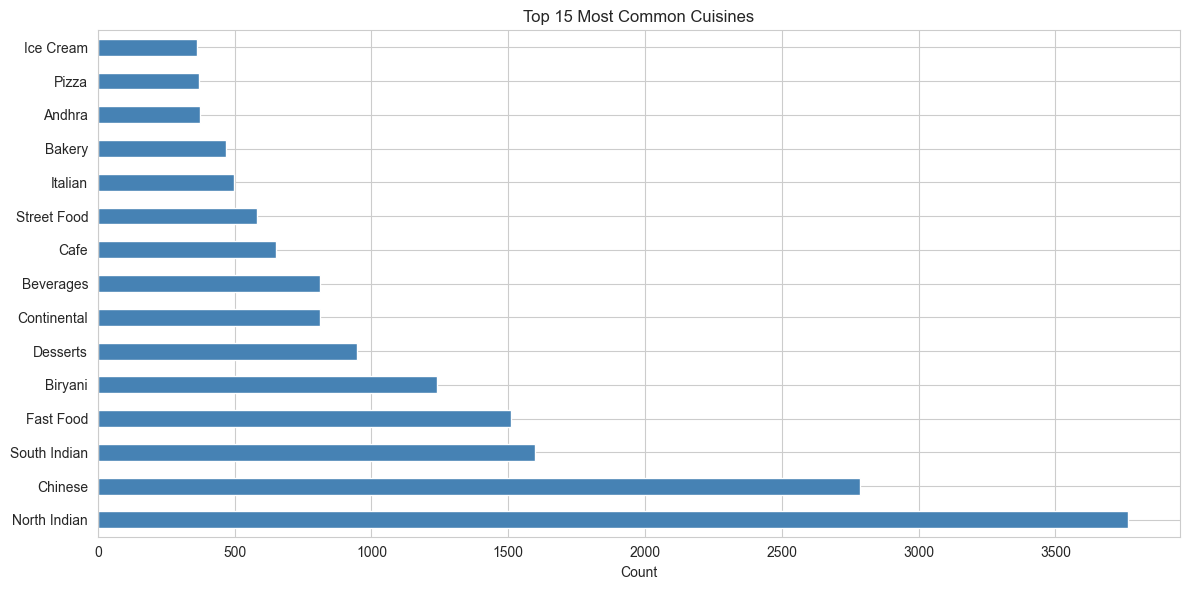

In [56]:
# Top cuisines overall
print('🍛 CUISINE ANALYSIS')
print('=' * 70)

all_cuisines = []
for cuisine_str in df_clean['cuisines'].dropna():
    cuisines = [c.strip() for c in str(cuisine_str).split(',')]
    all_cuisines.extend(cuisines)

top_15_cuisines = pd.Series(all_cuisines).value_counts().head(15)

print(f'\nTop 15 Most Common Cuisines:')
for idx, (cuisine, count) in enumerate(top_15_cuisines.items(), 1):
    pct = (count / len(all_cuisines)) * 100
    print(f'{idx:2d}. {cuisine:25s} → {count:4d} ({pct:5.1f}%)')

# Visualize
plt.figure(figsize=(12, 6))
top_15_cuisines.plot(kind='barh', color='steelblue')
plt.xlabel('Count')
plt.title('Top 15 Most Common Cuisines')
plt.tight_layout()
plt.show()


⭐ CUISINES BY AVERAGE RATING

(Only cuisines with 10+ restaurants)
 1. Modern Indian             →  4.26 ⭐ ( 20 restaurants)
 2. Malaysian                 →  4.22 ⭐ ( 18 restaurants)
 3. Japanese                  →  4.22 ⭐ ( 43 restaurants)
 4. Mediterranean             →  4.19 ⭐ ( 85 restaurants)
 5. Konkan                    →  4.16 ⭐ ( 10 restaurants)
 6. European                  →  4.16 ⭐ (100 restaurants)
 7. Korean                    →  4.15 ⭐ ( 22 restaurants)
 8. Asian                     →  4.09 ⭐ (181 restaurants)
 9. Indonesian                →  4.05 ⭐ ( 13 restaurants)
10. Steak                     →  4.05 ⭐ ( 75 restaurants)
11. French                    →  4.03 ⭐ ( 16 restaurants)
12. BBQ                       →  4.00 ⭐ (123 restaurants)
13. Turkish                   →  3.98 ⭐ ( 18 restaurants)
14. American                  →  3.97 ⭐ (199 restaurants)
15. Vietnamese                →  3.96 ⭐ ( 31 restaurants)


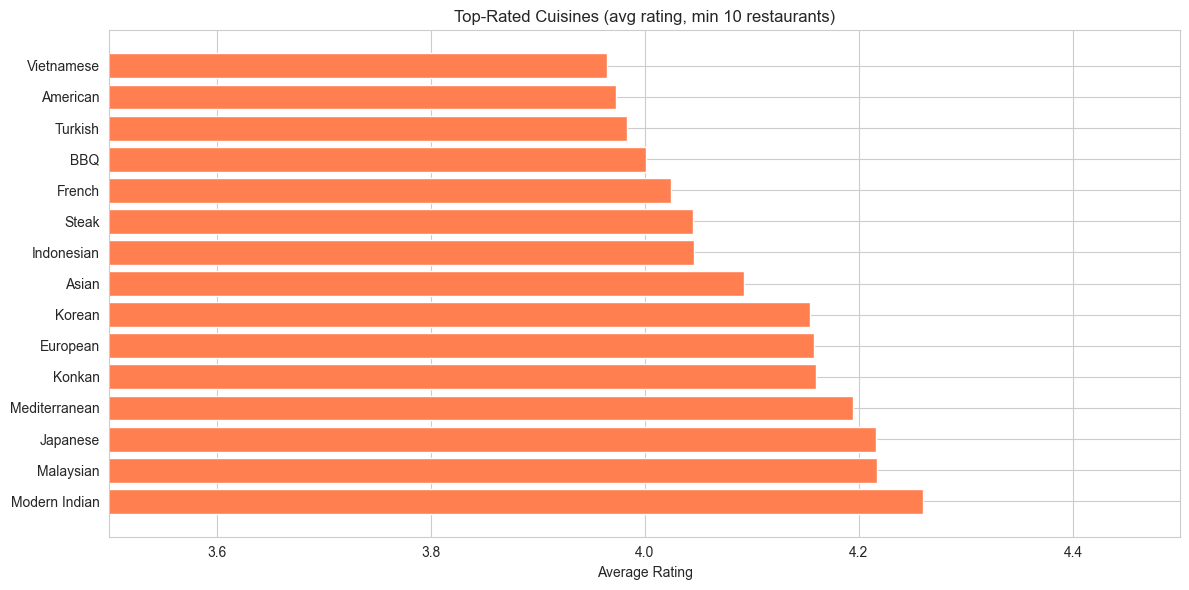

In [57]:
# Highest-rated cuisines
print('\n⭐ CUISINES BY AVERAGE RATING')
print('=' * 70)

# Create a mapping of cuisines to ratings
cuisine_ratings = {}
cuisine_counts = {}

for _, row in df_clean.iterrows():
    cuisines = [c.strip() for c in str(row['cuisines']).split(',')]
    for cuisine in cuisines:
        if cuisine not in cuisine_ratings:
            cuisine_ratings[cuisine] = []
            cuisine_counts[cuisine] = 0
        cuisine_ratings[cuisine].append(row['rate'])
        cuisine_counts[cuisine] += 1

# Calculate avg ratings
cuisine_avg_rating = {cuisine: np.mean(ratings) for cuisine, ratings in cuisine_ratings.items()}

# Filter cuisines with at least 10 restaurants
cuisine_avg_rating_filtered = {k: v for k, v in cuisine_avg_rating.items() if cuisine_counts[k] >= 10}

# Sort by rating
top_rated_cuisines = sorted(cuisine_avg_rating_filtered.items(), key=lambda x: x[1], reverse=True)[:15]

print(f'\n(Only cuisines with 10+ restaurants)')
for idx, (cuisine, avg_rating) in enumerate(top_rated_cuisines, 1):
    count = cuisine_counts[cuisine]
    print(f'{idx:2d}. {cuisine:25s} → {avg_rating:5.2f} ⭐ ({count:3d} restaurants)')

# Visualize
plt.figure(figsize=(12, 6))
cuisines = [x[0] for x in top_rated_cuisines]
ratings = [x[1] for x in top_rated_cuisines]
plt.barh(cuisines, ratings, color='coral')
plt.xlabel('Average Rating')
plt.title('Top-Rated Cuisines (avg rating, min 10 restaurants)')
plt.xlim(3.5, 4.5)
plt.tight_layout()
plt.show()

### 📌 DATA INSIGHT: Cuisine Trends

**What does this data show?**
- North Indian, Chinese, and Italian are the top cuisines overall
- But highest-rated cuisines are different (specialty cuisines like Continental, Mediterranean)
- Fine dine cuisines punch above their weight in ratings

**User/Business Problem:**
- Users searching for "fine dine" experience don't have good filtering
- Specialty cuisines are buried under mainstream options

**Product Opportunity:**
🎯 **Use cuisine preferences in Hidden Gems personalization**
- If user searches "Continental cuisine", show hidden gems in that category
- This makes the feature MORE RELEVANT and PERSONALIZED

---

# FINAL SUMMARY: 5 KEY PRODUCT INSIGHTS FROM EDA

These insights directly inform the PRD and Wireframe in Parts 2 and 3.

## 🎯 Key Product Insights from EDA

### 1. **Hidden Gems Are Undiscovered Quality** 
**Finding →** 200-300 restaurants have 4.0+ ratings but <200 votes (hidden gems)
**Problem →** Users miss quality restaurants due to poor visibility; good restaurants suffer from discovery bias
**Opportunity →** Curated "Hidden Gems" section surfaces high-quality, low-visibility restaurants → increases discovery diversity

### 2. **Geographic Imbalance Creates Service Gaps**
**Finding →** 35-40% of restaurants concentrated in 3 locations; 50+ locations underserved (5-15 restaurants each)
**Problem →** Users in premium areas suffer discovery fatigue; users in emerging areas have limited options
**Opportunity →** Hidden Gems prioritizes tier-2 locations → better inventory distribution & expansion opportunity

### 3. **Table Booking is a Quality Signal**
**Finding →** Restaurants with table booking have ~0.25 higher average rating; 25-30% offer table booking
**Problem →** Users can't distinguish between casual chains and fine dine in main feed
**Opportunity →** Filter Hidden Gems to only include table-bookable restaurants → ensures quality + aligns with Swiggy Dineout's core use case

### 4. **Dine-In Discovery Gap Exists**
**Finding →** 70-75% restaurants are delivery-focused; dine-in restaurants differ in cuisine, quality, and use case
**Problem →** Swiggy Dineout's discovery is mixed with delivery (confusing); quality dine-in gems get buried
**Opportunity →** Separate "dine-in curation" via Hidden Gems → clarifies Swiggy Dineout's differentiation vs Zomato

### 5. **Price Personalization Drives Relevance**
**Finding →** 70% restaurants in mid-range (₹300-600); budget & ultra-premium segments underserved; cost varies by location
**Problem →** One-size-fits-all discovery doesn't match user budgets & occasion types
**Opportunity →** Personalize Hidden Gems by price segment → shows relevant restaurants for user's budget & occasion

In [58]:
# Exports: top gems and key figures
import os
out_dir = 'outputs'
os.makedirs(out_dir, exist_ok=True)

# Export top 10 hidden gems (use `top_gems` if present, otherwise derive)
if 'top_gems' in globals():
    top_gems.to_csv(os.path.join(out_dir, 'top_10_hidden_gems.csv'), index=False)
else:
    hidden_gems.head(10).to_csv(os.path.join(out_dir, 'top_10_hidden_gems.csv'), index=False)

# Save full hidden gems table
hidden_gems.to_csv(os.path.join(out_dir, 'hidden_gems_full.csv'), index=False)

# Cost histogram
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8,4))
ax.hist(df_clean['approx_cost(for two people)'], bins=40, color='steelblue', edgecolor='black')
ax.set_xlabel('Cost for Two People (₹)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Restaurant Costs')
ax.axvline(df_clean['approx_cost(for two people)'].median(), color='red', linestyle='--')
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'cost_histogram.png'))
plt.close(fig)

# Pie chart by segment
if 'segment_counts' in globals():
    sc = segment_counts.reindex(['Budget (<₹300)', 'Mid-Range (₹300-600)', 'Premium (₹600-1000)', 'Ultra-Premium (>₹1000)'], fill_value=0)
else:
    sc = df_clean['cost_segment'].value_counts().reindex(['Budget (<₹300)', 'Mid-Range (₹300-600)', 'Premium (₹600-1000)', 'Ultra-Premium (>₹1000)'], fill_value=0)
existing_segments = [s for s in sc.index if sc[s] > 0]
existing_counts = [int(sc[s]) for s in existing_segments]
fig, ax = plt.subplots(figsize=(6,6))
ax.pie(existing_counts, labels=existing_segments, autopct='%1.1f%%', startangle=90)
ax.set_title('Restaurant Distribution by Price Segment')
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'cost_pie.png'))
plt.close(fig)

# Top cuisines
if 'top_15_cuisines' in globals():
    fig, ax = plt.subplots(figsize=(8,6))
    top_15_cuisines.sort_values().plot(kind='barh', color='teal', ax=ax)
    ax.set_title('Top 15 Cuisines by Count')
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, 'top_15_cuisines.png'))
    plt.close(fig)

# Ratings distribution
fig, ax = plt.subplots(figsize=(8,6))
df_clean['rate'].plot(kind='hist', bins=20, color='orange', edgecolor='black', ax=ax)
ax.set_title('Ratings Distribution')
ax.set_xlabel('Rating')
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'ratings_distribution.png'))
plt.close(fig)

print('Exports saved to', out_dir)


Exports saved to outputs


In [59]:
# Write final 5 key insights to a markdown file in outputs
import os
out_dir = 'outputs'
md_path = os.path.join(out_dir, 'final_5_insights.md')

insights = []
# 1. Hidden gems summary
if 'hidden_gems' in globals():
    insights.append(f"1. Hidden Gems identified: {len(hidden_gems)} (avg rating {hidden_gems['rate'].mean():.2f}, avg votes {int(hidden_gems['votes'].mean())}, avg cost ₹{int(hidden_gems['approx_cost(for two people)'].mean())})")
else:
    insights.append("1. Hidden Gems identified: (see notebook)")

# 2. Cost distribution
budget_count = int(segment_dist.get('Budget (<₹300)', 0))
mid_count = int(segment_dist.get('Mid-Range (₹300-600)', 0))
premium_count = int(segment_dist.get('Premium (₹600-1000)', 0))
total = len(df_clean)
insights.append(f"2. Cost distribution — Budget: {budget_count} ({budget_count/total*100:.1f}%), Mid-Range: {mid_count} ({mid_count/total*100:.1f}%), Premium: {premium_count} ({premium_count/total*100:.1f}%)")

# 3. Average rating
insights.append(f"3. Average rating across cleaned dataset: {df_clean['rate'].mean():.2f} (median {df_clean['rate'].median():.2f})")

# 4. Book-table insight (computed from df_clean)
book_yes_mean = df_clean[df_clean['book_table'] == 'Yes']['rate'].mean()
book_no_mean = df_clean[df_clean['book_table'] != 'Yes']['rate'].mean()
insights.append(f"4. Restaurants with book-table available have higher average rating: {book_yes_mean:.2f} vs {book_no_mean:.2f}")

# 5. Top cuisines
if 'top_15_cuisines' in globals():
    top5 = ', '.join(top_15_cuisines.head(5).index.tolist())
    insights.append(f"5. Top cuisines: {top5}")
else:
    insights.append("5. Top cuisines analysis available in notebook.")

with open(md_path, 'w', encoding='utf-8') as f:
    f.write('# Final 5 Key Insights\n\n')
    for i in insights:
        f.write(f'- {i}\n')

print('Wrote', md_path)


Wrote outputs\final_5_insights.md
